In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
import logging

from pcntoolkit import (
    BLR,
    BsplineBasisFunction,
    LinearBasisFunction,
    NormativeModel,
    NormData,
    load_fcon1000,
    plot_centiles_advanced,
    plot_qq,
    plot_ridge,
)

import pcntoolkit.util.output
import seaborn as sns

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")

pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
pcntoolkit.util.output.Output.set_show_messages(True)

In [2]:
path = "/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Data"
train_data = pd.read_csv(os.path.join(path, "B2_1.csv"))
train_data = train_data.iloc[:,1:]
test_data = pd.read_csv(os.path.join(path, "B2_2.csv"))
test_data = test_data.iloc[:,1:]
train_data


,Age,Sex,Site,Diagnosis,Dataset,3rd-Ventricle,4th-Ventricle,Brain-Stem,CC_Anterior,CC_Central,...,rh_S_front_sup_thickness,rh_S_interm_prim-Jensen_thickness,rh_S_oc-temp_lat_thickness,rh_S_occipital_ant_thickness,rh_S_parieto_occipital_thickness,rh_S_pericallosal_thickness,rh_S_postcentral_thickness,rh_S_precentral-inf-part_thickness,rh_S_precentral-sup-part_thickness,rh_S_temporal_sup_thickness
0,67.0,0.0,11025.0,0.0,UKB,2264.4,1757.6,16675.6,911.2,470.7,...,2.775,2.666,3.012,2.805,2.371,3.076,2.413,2.865,2.383,2.890
1,63.0,1.0,11025.0,0.0,UKB,1489.0,1549.5,28505.6,912.7,508.3,...,2.748,2.990,2.474,2.197,2.580,2.097,2.201,2.985,2.621,2.437
2,47.0,0.0,11025.0,0.0,UKB,850.9,1643.5,21648.4,988.0,725.1,...,2.547,2.875,2.503,2.345,2.317,2.054,2.095,2.510,2.399,2.555
3,70.0,1.0,11025.0,0.0,UKB,2454.1,2209.5,20450.0,800.0,541.0,...,2.825,2.771,2.689,2.660,2.528,2.109,2.398,2.930,2.509,2.654
4,56.0,1.0,11027.0,0.0,UKB,1910.3,1577.8,23725.4,720.8,462.3,...,2.765,2.409,2.820,2.543,2.536,1.821,2.319,2.601,2.859,2.691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4067,85.0,1.0,99.0,1.0,ADNI,2806.9,1534.4,21560.7,1110.4,533.6,...,2.130,2.080,2.399,2.125,2.079,1.529,2.084,2.313,2.068,2.322
4068,85.0,1.0,18.0,1.0,ADNI,1145.0,1484.2,18359.7,617.7,459.8,...,2.245,1.817,2.005,2.034,1.889,1.996,1.674,2.258,2.047,2.070
4069,68.0,0.0,100.0,1.0,ADNI,960.3,1324.0,18422.0,566.5,357.7,...,2.363,2.405,2.442,2.163,1.977,1.513,2.028,2.411,2.021,2.432
4070,80.0,1.0,401.0,2.0,OASIS3,1698.7,2349.7,22581.7,792.8,279.4,...,2.308,1.865,2.632,2.057,2.183,2.614,1.777,2.163,2.229,2.380


In [11]:
model_path = "/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/BLR/Final_BLRs/Final_BLR_corrected_results"
model = NormativeModel.load(model_path)

data_df = train_data
demographic_data = train_data.iloc[:,:5]

data_df

data_df = data_df[~data_df["Site"].isin([9.0, 10.0, 14.0, 16.0, 19.0, 20.0, 24.0, 27.0, 35.0, 51.0, 57.0, 68.0, 62.0, 67.0, 70.0, 114.0, 130.0, 133.0, 135.0, 136.0, 141.0, 153.0])]
data_df = data_df[data_df["Site"].isin([128, 129, 2, 3, 6, 137, 11, 12, 13, 401, 11025, 11026, 11027, 403, 402, 405, 404, 11028, 23, 18, 22, 32, 33, 36, 37, 41, 941, 72, 73, 82, 99, 100, 109, 116, 123])]
#removing these ages because they had unique site & age combinations which could not be split 
data_df = data_df[data_df["Age"] != 96.0]
data_df = data_df[data_df["Age"] != 91.0]
data_df = data_df[data_df["Age"] != 95.0]
data_df = data_df[data_df["Age"] != 97.0]

data = data_df
covariates = ["Age"]
batch_effects = ["Sex", "Site"]

data_df = data_df.drop(columns=['Age','Sex','Site','Dataset', "Diagnosis"])
columns = list(data_df.columns)

response_vars = columns

# create a NormData object
norm_data = NormData.from_dataframe(
    name="Final_BLR_corrected", dataframe=data, covariates=covariates, batch_effects=batch_effects, response_vars=response_vars
)
norm_data.coords

predictions = model.predict(norm_data)



Process: 2594922 - 2026-05-15 10:43:08 - Dataset "Final_BLR_corrected" created.
    - 3929 observations
    - 3929 unique subjects
    - 1 covariates
    - 103 response variables
    - 2 batch effects:
    	Sex (2)
	Site (35)
    
Process: 2594922 - 2026-05-15 10:43:08 - Making predictions on 103 response variables.
Process: 2594922 - 2026-05-15 10:43:08 - Computing z-scores for 103 response variables.
Process: 2594922 - 2026-05-15 10:43:08 - Computing z-scores for CC_Central.
Process: 2594922 - 2026-05-15 10:43:08 - Computing z-scores for CC_Posterior.
Process: 2594922 - 2026-05-15 10:43:08 - Computing z-scores for Optic-Chiasm.
Process: 2594922 - 2026-05-15 10:43:08 - Computing z-scores for rh_S_front_sup_thickness.
Process: 2594922 - 2026-05-15 10:43:08 - Computing z-scores for rh_S_pericallosal_thickness.
Process: 2594922 - 2026-05-15 10:43:08 - Computing z-scores for rh_S_parieto_occipital_thickness.
Process: 2594922 - 2026-05-15 10:43:08 - Computing z-scores for lh_S_pericallosal

/home/preclineu/quirom/.conda/envs/norm_vae/lib/python3.12/site-packages/pcntoolkit/dataio/norm_data.py:1051: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_results = old_results.merge(zdf, on="observations", how="outer", suffixes=("_old", ""))
/home/preclineu/quirom/.conda/envs/norm_vae/lib/python3.12/site-packages/pcntoolkit/dataio/norm_data.py:1107: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_results = old_results.merge(centiles, on=["observations", "centile"], how="outer", suffixes=("_old", ""))
/home/preclineu/quir

Process: 2594922 - 2026-05-15 10:47:26 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 103 response variables
    - 2 batch effects:
    	Sex (1)
	Site (1)
    
Process: 2594922 - 2026-05-15 10:47:26 - Computing centiles for 103 response variables.
Process: 2594922 - 2026-05-15 10:47:26 - Computing centiles for CC_Central.
Process: 2594922 - 2026-05-15 10:47:26 - Computing centiles for CC_Posterior.
Process: 2594922 - 2026-05-15 10:47:26 - Computing centiles for Optic-Chiasm.
Process: 2594922 - 2026-05-15 10:47:26 - Computing centiles for rh_S_front_sup_thickness.
Process: 2594922 - 2026-05-15 10:47:26 - Computing centiles for rh_S_pericallosal_thickness.
Process: 2594922 - 2026-05-15 10:47:26 - Computing centiles for rh_S_parieto_occipital_thickness.
Process: 2594922 - 2026-05-15 10:47:26 - Computing centiles for lh_S_pericallosal_thickness.
Process: 2594922 - 2026-05-15 10:47:26 - Computing centiles for Left-Cerebellum-Cortex.
Pr

In [23]:
df = predictions.to_dataframe()
df_age = df["X"].reset_index(drop=True)
df_z = df["Z"].reset_index(drop=True)
df_batch = df["batch_effects"].reset_index(drop=True)
df_data = pd.concat([df_age, df_batch], axis=1)
df_diag = demographic_data["Diagnosis"].reset_index(drop=True)
df_train_data = pd.concat([df_data, df_diag, df_z], axis=1)

df_train_data = df_train_data.dropna()
df_train_data

,Age,Sex,Site,Diagnosis,3rd-Ventricle,4th-Ventricle,Brain-Stem,CC_Anterior,CC_Central,CC_Mid_Anterior,...,rh_S_front_sup_thickness,rh_S_interm_prim-Jensen_thickness,rh_S_oc-temp_lat_thickness,rh_S_occipital_ant_thickness,rh_S_parieto_occipital_thickness,rh_S_pericallosal_thickness,rh_S_postcentral_thickness,rh_S_precentral-inf-part_thickness,rh_S_precentral-sup-part_thickness,rh_S_temporal_sup_thickness
0,67.0,0.0,11025.0,0.0,1.382526,-0.036511,-1.331440,0.231803,0.014285,-0.495889,...,0.977715,0.621780,1.823990,1.737243,-0.092005,2.283937,0.668834,1.388687,-0.903637,1.641978
1,63.0,1.0,11025.0,0.0,-0.671644,-1.052933,2.092887,-0.187759,0.269956,0.929125,...,0.667044,1.934672,-1.229359,-1.367170,1.136063,0.303211,-0.629169,2.054823,0.232653,-1.423365
2,47.0,0.0,11025.0,0.0,-0.518085,-0.033399,0.222661,0.320412,1.428663,1.632959,...,-1.286204,0.985462,-1.238787,-1.190943,-0.985707,-0.213850,-1.670689,-1.338993,-1.492212,-1.371292
3,70.0,1.0,11025.0,0.0,0.510103,0.323233,-0.959068,-0.810443,0.995220,-0.598671,...,1.519094,1.336971,0.157660,1.195868,1.145451,0.305869,0.852628,1.979651,-0.158153,-0.048400
4,56.0,1.0,11027.0,0.0,0.826968,-0.941092,0.355689,-1.640863,-0.530298,-0.608014,...,0.416171,-0.833129,0.635440,0.261740,0.589380,-0.670660,-0.191370,-0.630262,1.408574,-0.377110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3924,85.0,1.0,99.0,1.0,0.294026,-1.061967,0.730668,2.070777,2.155330,2.337820,...,-0.204145,0.072292,0.455101,0.203828,0.278603,-0.002463,0.829480,0.078259,-0.189548,0.110461
3925,85.0,1.0,18.0,1.0,-1.974501,-1.158223,-1.080766,-1.755934,0.143253,-0.536925,...,0.165719,-0.362934,-0.678674,-0.010215,-0.143377,0.954727,-0.346288,0.092889,-0.163684,-0.615792
3926,68.0,0.0,100.0,1.0,-1.131581,-1.053759,-0.532773,-1.622443,-1.050589,-0.362705,...,0.294141,0.582447,-0.201693,-0.223680,-0.473906,-0.651283,-0.001167,0.251107,-0.705485,0.022773
3927,80.0,1.0,401.0,1.0,-0.394802,0.422937,0.590058,0.163684,-0.604145,-0.359345,...,0.366294,-0.361046,1.198896,-0.330967,0.708455,1.397806,-0.306801,-0.018163,0.227196,0.373751


In [27]:
model_path = "/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/BLR/Final_BLRs/Final_BLR_corrected_results"
model = NormativeModel.load(model_path)

data_df = test_data
demographic_data = test_data.iloc[:,:5]

data_df

data_df = data_df[~data_df["Site"].isin([9.0, 10.0, 14.0, 16.0, 19.0, 20.0, 24.0, 27.0, 35.0, 51.0, 57.0, 68.0, 62.0, 67.0, 70.0, 114.0, 130.0, 133.0, 135.0, 136.0, 141.0, 153.0])]
data_df = data_df[data_df["Site"].isin([128, 129, 2, 3, 6, 137, 11, 12, 13, 401, 11025, 11026, 11027, 403, 402, 405, 404, 11028, 23, 18, 22, 32, 33, 36, 37, 41, 941, 72, 73, 82, 99, 100, 109, 116, 123])]
#removing these ages because they had unique site & age combinations which could not be split 
data_df = data_df[data_df["Age"] != 96.0]
data_df = data_df[data_df["Age"] != 91.0]
data_df = data_df[data_df["Age"] != 95.0]
data_df = data_df[data_df["Age"] != 97.0]

data = data_df
covariates = ["Age"]
batch_effects = ["Sex", "Site"]

data_df = data_df.drop(columns=['Age','Sex','Site','Dataset', "Diagnosis"])
columns = list(data_df.columns)

response_vars = columns

# create a NormData object
norm_data = NormData.from_dataframe(
    name="Final_BLR_corrected", dataframe=data, covariates=covariates, batch_effects=batch_effects, response_vars=response_vars
)
norm_data.coords

predictions = model.predict(norm_data)


Process: 2594922 - 2026-05-15 10:57:08 - Dataset "Final_BLR_corrected" created.
    - 3912 observations
    - 3912 unique subjects
    - 1 covariates
    - 103 response variables
    - 2 batch effects:
    	Sex (2)
	Site (33)
    
Process: 2594922 - 2026-05-15 10:57:08 - Making predictions on 103 response variables.
Process: 2594922 - 2026-05-15 10:57:08 - Computing z-scores for 103 response variables.
Process: 2594922 - 2026-05-15 10:57:08 - Computing z-scores for CC_Central.
Process: 2594922 - 2026-05-15 10:57:08 - Computing z-scores for CC_Posterior.
Process: 2594922 - 2026-05-15 10:57:08 - Computing z-scores for Optic-Chiasm.
Process: 2594922 - 2026-05-15 10:57:08 - Computing z-scores for rh_S_front_sup_thickness.
Process: 2594922 - 2026-05-15 10:57:08 - Computing z-scores for rh_S_pericallosal_thickness.
Process: 2594922 - 2026-05-15 10:57:08 - Computing z-scores for rh_S_parieto_occipital_thickness.
Process: 2594922 - 2026-05-15 10:57:08 - Computing z-scores for lh_S_pericallosal

/home/preclineu/quirom/.conda/envs/norm_vae/lib/python3.12/site-packages/pcntoolkit/dataio/norm_data.py:1051: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_results = old_results.merge(zdf, on="observations", how="outer", suffixes=("_old", ""))
/home/preclineu/quirom/.conda/envs/norm_vae/lib/python3.12/site-packages/pcntoolkit/dataio/norm_data.py:1107: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_results = old_results.merge(centiles, on=["observations", "centile"], how="outer", suffixes=("_old", ""))
/home/preclineu/quir

Process: 2594922 - 2026-05-15 11:01:41 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 103 response variables
    - 2 batch effects:
    	Sex (1)
	Site (1)
    
Process: 2594922 - 2026-05-15 11:01:41 - Computing centiles for 103 response variables.
Process: 2594922 - 2026-05-15 11:01:41 - Computing centiles for CC_Central.
Process: 2594922 - 2026-05-15 11:01:41 - Computing centiles for CC_Posterior.
Process: 2594922 - 2026-05-15 11:01:41 - Computing centiles for Optic-Chiasm.
Process: 2594922 - 2026-05-15 11:01:41 - Computing centiles for rh_S_front_sup_thickness.
Process: 2594922 - 2026-05-15 11:01:41 - Computing centiles for rh_S_pericallosal_thickness.
Process: 2594922 - 2026-05-15 11:01:41 - Computing centiles for rh_S_parieto_occipital_thickness.
Process: 2594922 - 2026-05-15 11:01:41 - Computing centiles for lh_S_pericallosal_thickness.
Process: 2594922 - 2026-05-15 11:01:41 - Computing centiles for Left-Cerebellum-Cortex.
Pr

In [28]:
df = predictions.to_dataframe()
df_age = df["X"].reset_index(drop=True)
df_z = df["Z"].reset_index(drop=True)
df_batch = df["batch_effects"].reset_index(drop=True)
df_data = pd.concat([df_age, df_batch], axis=1)
df_diag = demographic_data["Diagnosis"].reset_index(drop=True)
df_test_data = pd.concat([df_data, df_diag, df_z], axis=1)

df_test_data = df_test_data.dropna()
df_test_data

,Age,Sex,Site,Diagnosis,3rd-Ventricle,4th-Ventricle,Brain-Stem,CC_Anterior,CC_Central,CC_Mid_Anterior,...,rh_S_front_sup_thickness,rh_S_interm_prim-Jensen_thickness,rh_S_oc-temp_lat_thickness,rh_S_occipital_ant_thickness,rh_S_parieto_occipital_thickness,rh_S_pericallosal_thickness,rh_S_postcentral_thickness,rh_S_precentral-inf-part_thickness,rh_S_precentral-sup-part_thickness,rh_S_temporal_sup_thickness
0,59.0,1.0,11027.0,0.0,1.087282,0.561486,-0.913112,0.542030,0.230749,0.576783,...,0.004307,-0.388572,-0.901221,1.129875,-0.036098,0.596872,-0.270189,0.336870,0.280144,0.064358
1,52.0,1.0,11025.0,0.0,1.882855,0.990653,-0.618527,-0.775827,0.019506,-0.673822,...,1.230074,-0.087199,1.247200,2.033349,0.311030,0.359975,0.880727,1.005340,1.010526,0.588725
2,54.0,0.0,11025.0,0.0,-0.722810,-0.708910,0.309145,-0.133461,-0.081379,-0.988084,...,1.040774,1.805861,-1.160633,0.207052,1.321645,-0.804882,0.034093,1.048356,-0.669652,-0.163165
3,53.0,1.0,11025.0,0.0,1.579660,1.856553,1.442546,-0.524985,0.018231,0.267623,...,0.250011,0.080812,-0.750578,-0.390135,0.050454,0.482340,0.591741,0.375220,-0.443187,0.610748
4,52.0,1.0,11027.0,0.0,-0.338669,0.895261,1.268439,0.820037,-0.437262,-0.253265,...,0.291879,0.471686,0.224831,-0.562704,0.602519,0.917472,-0.293590,-0.326918,1.338861,0.411022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3907,70.0,1.0,6.0,1.0,-0.608404,0.157790,0.825159,1.918032,0.778591,1.484651,...,0.220250,-0.273832,0.579460,0.200148,0.524085,-0.458912,0.201592,-0.011211,0.173374,0.069594
3908,79.0,0.0,2.0,1.0,-0.092428,1.387422,-0.062812,-0.430191,-0.571530,-0.809977,...,0.004400,-0.068696,0.293078,-0.640896,0.616929,-0.316530,0.450605,-0.158735,-0.357892,0.379999
3909,80.0,1.0,116.0,2.0,0.996825,0.053612,-1.597952,-0.487967,-1.376577,-0.251889,...,-0.145382,0.077206,-0.896189,-0.329887,-0.226092,-0.556010,-0.078021,-0.131508,0.012810,-0.528340
3910,77.0,1.0,13.0,1.0,0.900944,0.089642,1.359099,-0.598768,-0.413848,-0.469113,...,-0.637469,-0.070429,-0.332341,-0.018279,0.070339,1.477545,0.303519,0.245425,0.222878,-0.496041


In [12]:
import pandas as pd
df_train_data = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Data/B2_1_z_scored.csv")
df_test_data = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Data/B2_2_z_scored.csv")
# df_test_data = df_test_data.iloc[:,5:]
# df_train_data = df_train_data.iloc[:,5:]


# If these are true normative z-scores, HC std should be ~1
# and AD/MCI std should be > 1
for diag, label in [(0, "HC"), (1, "MCI"), (2, "AD")]:
    group = df_train_data[df_train_data["Diagnosis"] == diag].drop(columns=["Diagnosis", "Age","Sex","Site"])
    print(label, "| std:", group.iloc[:,1:].values.std().round(3))


HC | std: 0.988
MCI | std: 0.788
AD | std: 0.794


,Unnamed: 0,Age,Sex,Site,Diagnosis,3rd-Ventricle,4th-Ventricle,Brain-Stem,CC_Anterior,CC_Central,...,rh_S_front_sup_thickness,rh_S_interm_prim-Jensen_thickness,rh_S_oc-temp_lat_thickness,rh_S_occipital_ant_thickness,rh_S_parieto_occipital_thickness,rh_S_pericallosal_thickness,rh_S_postcentral_thickness,rh_S_precentral-inf-part_thickness,rh_S_precentral-sup-part_thickness,rh_S_temporal_sup_thickness
3546,3546,72.0,0.0,401.0,2.0,0.589661,-1.355904,-0.209485,0.244839,0.361890,...,0.032953,-0.754205,-0.696703,-1.241719,-0.377028,-1.980971,0.311894,-0.108523,0.098793,-0.522666
3550,3550,89.0,1.0,405.0,2.0,0.527170,0.250009,2.271868,0.450319,0.180872,...,-0.638287,0.004353,0.373813,-0.159867,0.079332,-0.340671,0.026145,-0.432904,-0.390230,0.051383
3551,3551,80.0,1.0,401.0,2.0,-1.295782,-0.731485,-0.289546,0.186292,-0.049762,...,0.366294,0.042333,-0.007309,-0.391148,0.049000,-1.314362,0.758785,0.041422,0.248385,0.073311
3553,3553,61.0,0.0,401.0,2.0,-0.633311,-0.946797,-0.644198,0.265758,-0.215978,...,-0.579908,-0.781834,-0.874676,2.394415,-1.000845,-1.057467,-0.699220,-0.653029,0.018028,-0.346629
3555,3555,71.0,0.0,73.0,2.0,1.405993,1.343615,1.023882,0.789701,-0.495552,...,-0.586171,0.050033,-0.655552,0.142472,-0.149630,-0.896370,0.051325,-0.061000,-0.099570,-0.325163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3895,80.0,0.0,402.0,2.0,-0.683792,-0.786678,1.026170,1.346443,0.644057,...,0.203925,0.031964,-0.305909,0.028872,0.270628,-0.737645,-0.414387,0.477916,-0.248321,-0.053629
3899,3899,68.0,1.0,403.0,2.0,1.545707,1.746936,-0.204194,-0.935369,-0.473615,...,0.243089,-0.651592,-0.824571,0.005719,0.085051,-0.699583,-0.014841,0.016552,0.454515,0.107245
3900,3900,78.0,0.0,402.0,2.0,-0.880104,0.064248,-0.412050,0.458614,-0.059033,...,0.043203,0.245468,-0.177970,0.365887,0.975594,0.887555,-0.478992,0.653777,0.235751,0.714933
3908,3908,70.0,1.0,99.0,2.0,0.284628,1.223582,0.700068,-0.689386,-0.555824,...,-0.381627,-0.839495,-0.702595,-0.294248,-0.743533,-0.278594,-0.747279,-0.902122,-0.427295,-0.564832


MSE: 0.4172
MAE: 0.5000
R²: 0.5828

PC1:    Cummulative variance:  27.86%,  Individual variance:  27.86%
PC2:    Cummulative variance:  36.87%,  Individual variance:  9.00%
PC3:    Cummulative variance:  42.61%,  Individual variance:  5.75%
PC4:    Cummulative variance:  46.07%,  Individual variance:  3.45%
PC5:    Cummulative variance:  48.83%,  Individual variance:  2.76%
PC6:    Cummulative variance:  51.04%,  Individual variance:  2.21%
PC7:    Cummulative variance:  53.24%,  Individual variance:  2.20%
PC8:    Cummulative variance:  55.20%,  Individual variance:  1.96%
PC9:    Cummulative variance:  56.81%,  Individual variance:  1.61%
PC10:   Cummulative variance:  58.28%,  Individual variance:  1.47%


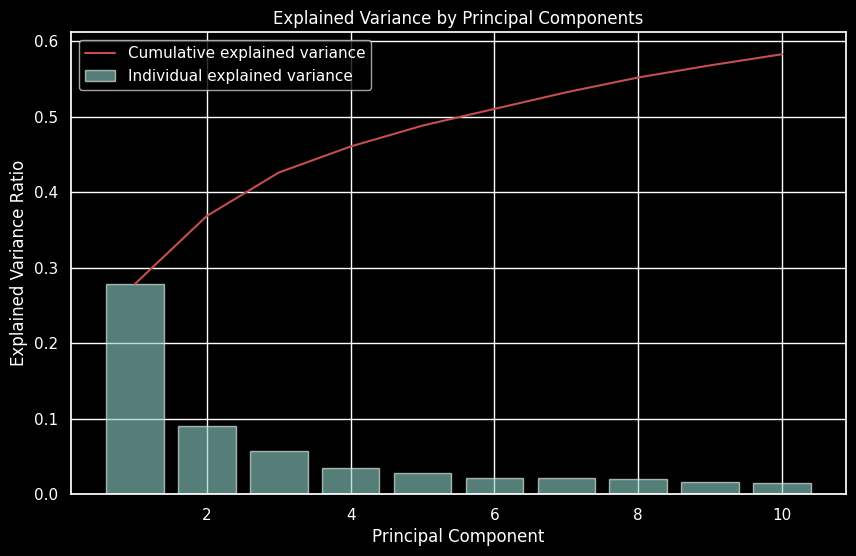



MSE: 0.4265
MAE: 0.5064
R²: 0.5735

PC1:    Cummulative variance:  27.86%,  Individual variance:  27.86%
PC2:    Cummulative variance:  36.87%,  Individual variance:  9.00%
PC3:    Cummulative variance:  42.61%,  Individual variance:  5.75%
PC4:    Cummulative variance:  46.07%,  Individual variance:  3.45%
PC5:    Cummulative variance:  48.83%,  Individual variance:  2.76%
PC6:    Cummulative variance:  51.04%,  Individual variance:  2.21%
PC7:    Cummulative variance:  53.24%,  Individual variance:  2.20%
PC8:    Cummulative variance:  55.20%,  Individual variance:  1.96%
PC9:    Cummulative variance:  56.81%,  Individual variance:  1.61%
PC10:   Cummulative variance:  58.28%,  Individual variance:  1.47%


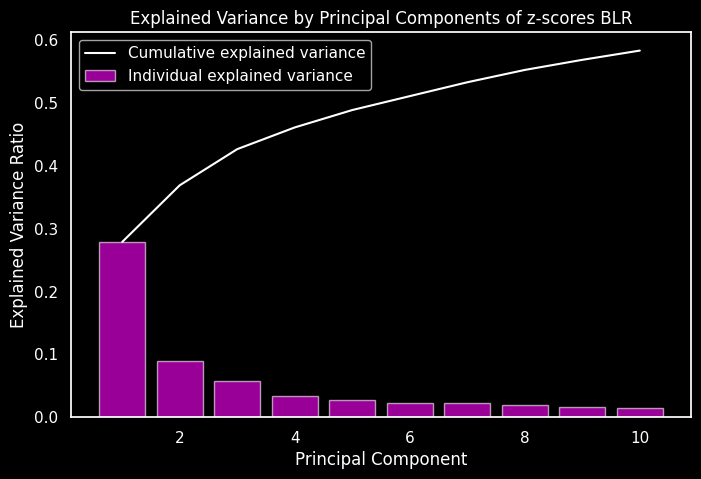

In [6]:
def run_pca_analysis(data, n_components=10):
    x = data
    scaler = StandardScaler()

    
    x_scaled = scaler.fit_transform(x)
    
    pca = PCA(n_components)

    x_pca = pca.fit_transform(x_scaled)

    #get scores
    x_recon = pca.inverse_transform(x_pca)
    mse = mean_squared_error(x_scaled, x_recon)
    mae = mean_absolute_error(x_scaled, x_recon)
    r2 = r2_score(x_scaled, x_recon)
    print(f"MSE: {mse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}\n")
    
    cummulative_variance = 0
    for i, var in enumerate(pca.explained_variance_ratio_, start=1):
        cummulative_variance += var
        if i < 10: 
            print(f'PC{i}:    Cummulative variance:  {cummulative_variance:.2%},  Individual variance:  {var:.2%}')
        else:
            print(f'PC{i}:   Cummulative variance:  {cummulative_variance:.2%},  Individual variance:  {var:.2%}')
    
    #plot
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.6, label='Individual explained variance')
    plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), 'r-', label='Cumulative explained variance')
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance Ratio')
    plt.title('Explained Variance by Principal Components')
    plt.legend()
    plt.show()
    return pca





pca = run_pca_analysis(df_train_data)
print('\n')

#get scores on test data
x = df_test_data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

#only transform the test data
x_pca = pca.transform(x_scaled)

#calculate the metrics
x_recon = pca.inverse_transform(x_pca)
mse = mean_squared_error(x_scaled, x_recon)
mae = mean_absolute_error(x_scaled, x_recon)
r2 = r2_score(x_scaled, x_recon)
print(f"MSE: {mse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}\n")

cummulative_variance = 0
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    cummulative_variance += var
    if i < 10: 
        print(f'PC{i}:    Cummulative variance:  {cummulative_variance:.2%},  Individual variance:  {var:.2%}')
    else:
        print(f'PC{i}:   Cummulative variance:  {cummulative_variance:.2%},  Individual variance:  {var:.2%}')

#plot
plt.style.use("dark_background")

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, color="fuchsia" ,alpha=0.6, label='Individual explained variance')
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), color="white", label='Cumulative explained variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components of z-scores BLR')
plt.grid(False)
plt.legend()
plt.show()


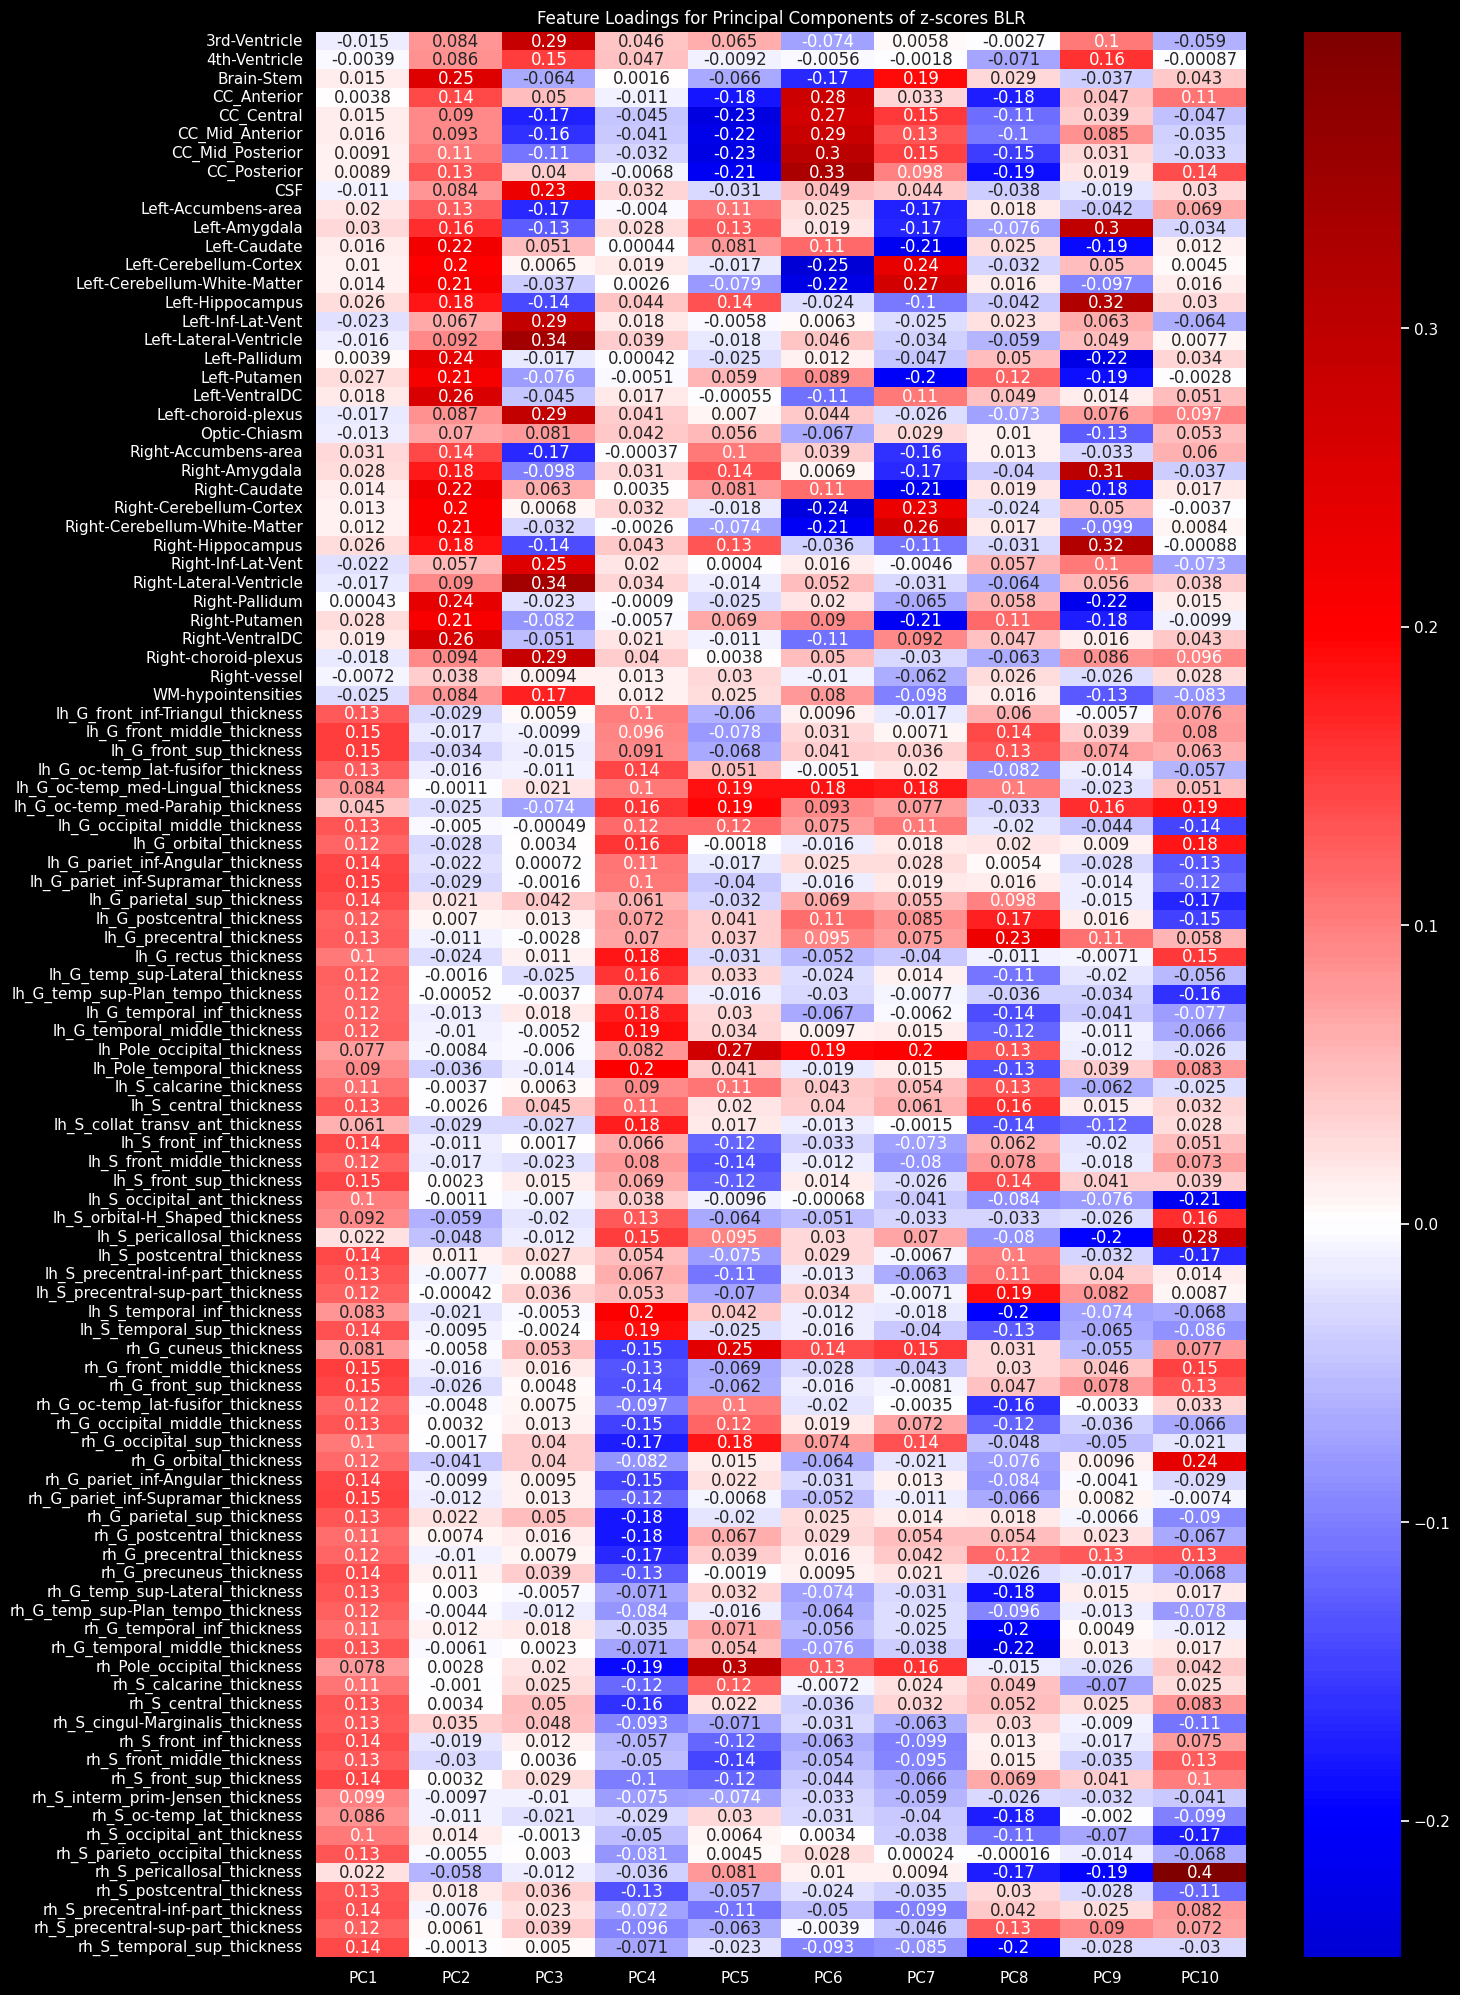

In [7]:
loadings = pca.components_
feature_names = df_test_data.columns
# print(feature_names)
# print(loadings.shape)


loadings_df = pd.DataFrame(loadings.T, columns=[f'PC{i+1}' for i in range(loadings.shape[0])], index=feature_names)
# loadings_df = loadings_df.columns.sort_values(ascending=False)
plt.figure(figsize=(15,25))
sns.heatmap(loadings_df.iloc[:, :10], annot=True, cmap='seismic', center=0)
plt.title('Feature Loadings for Principal Components of z-scores BLR')
plt.show()


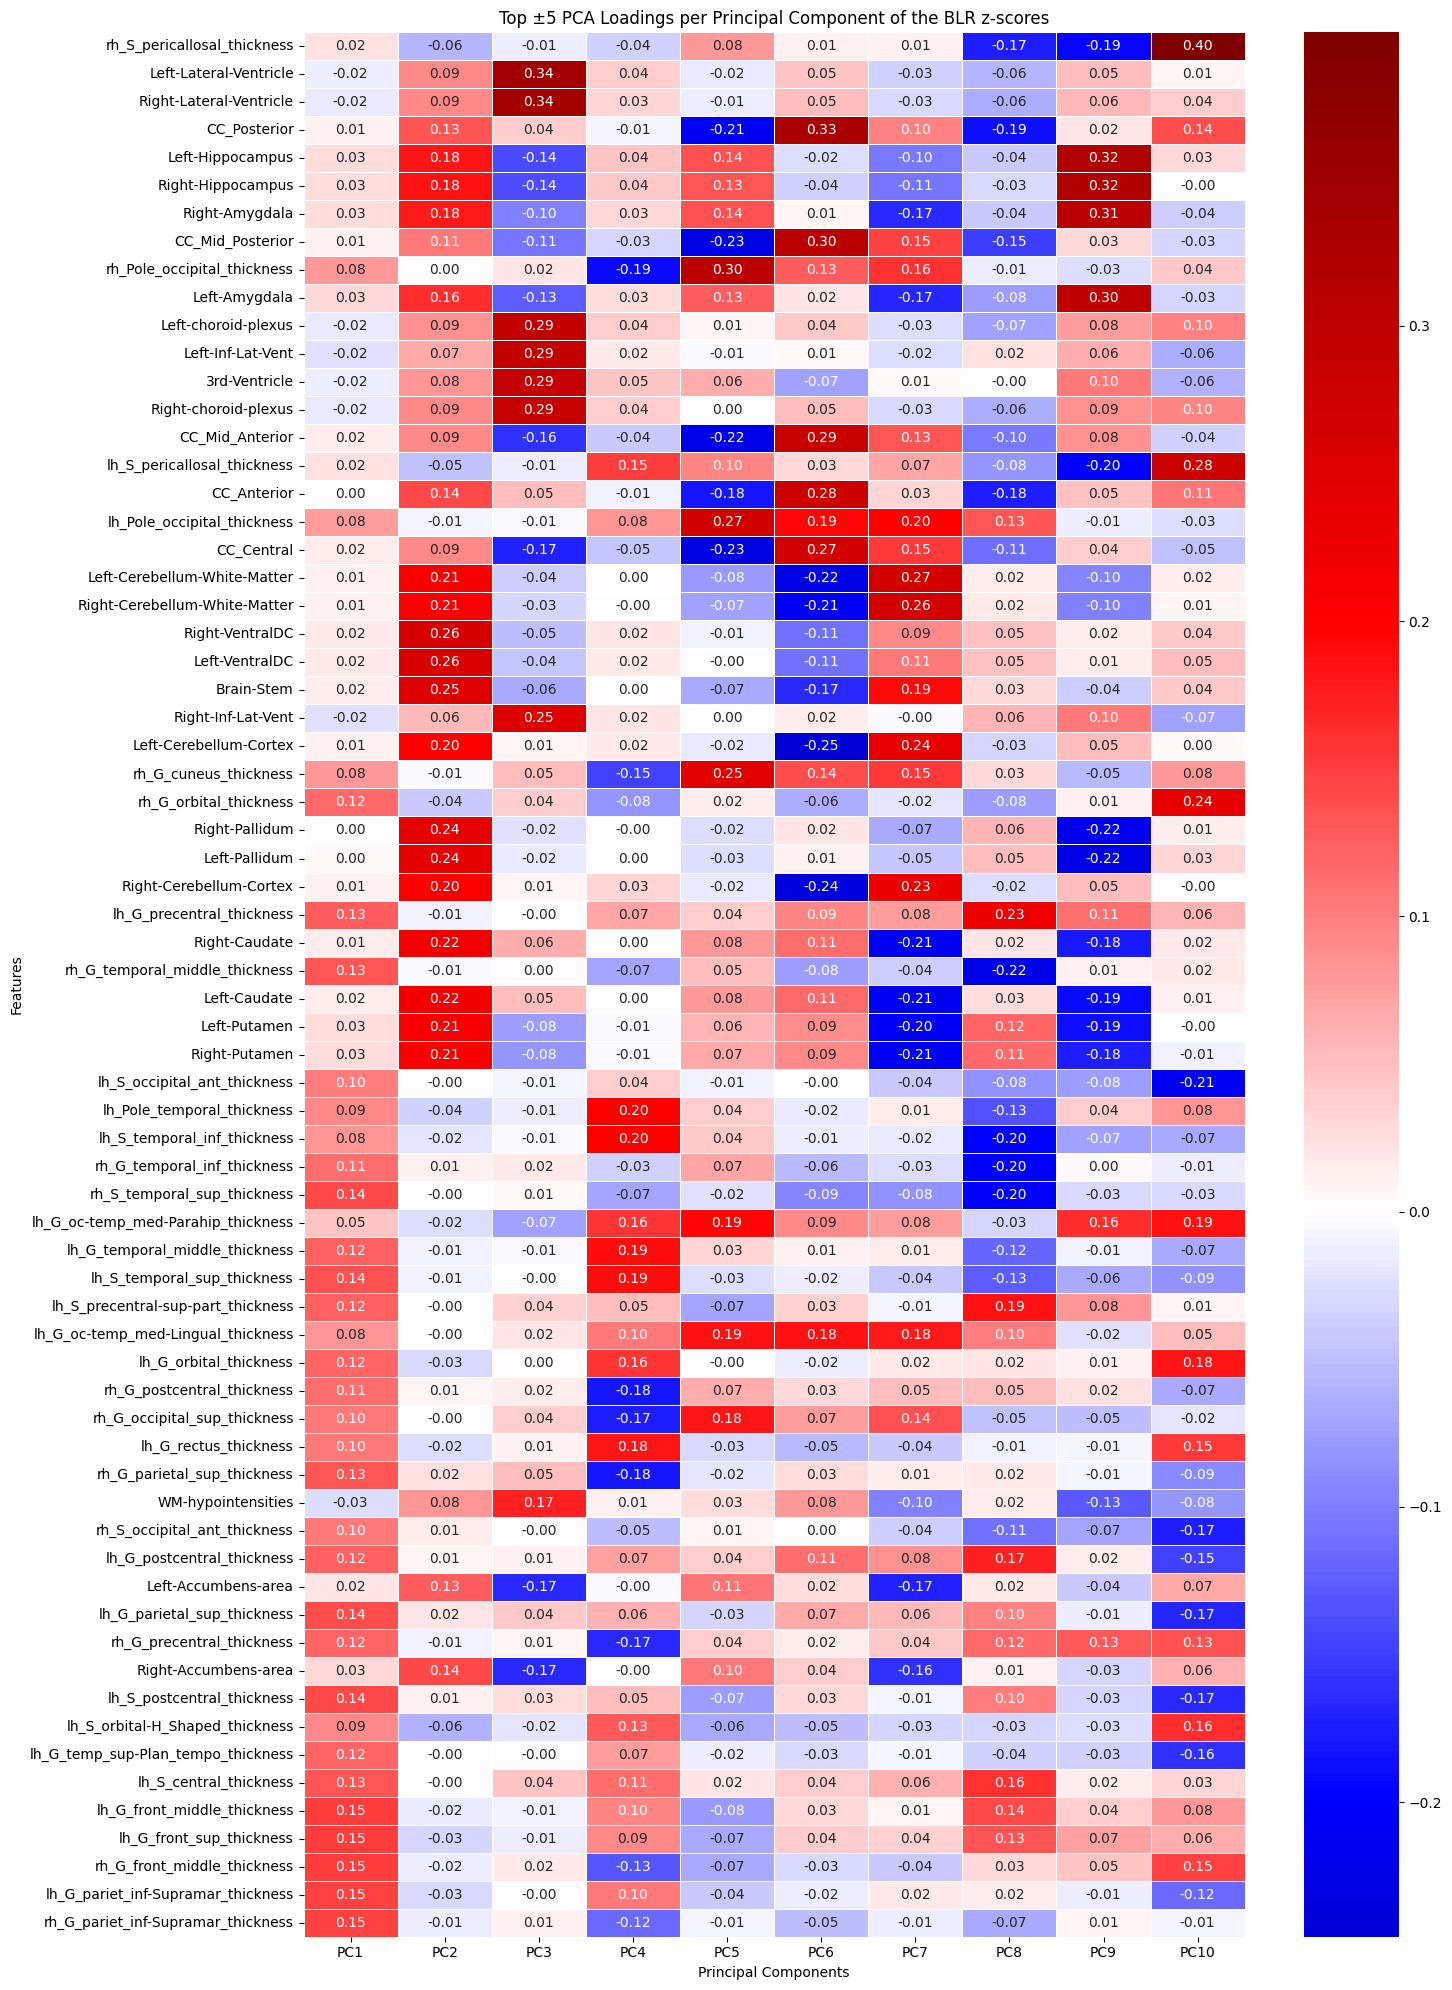

In [22]:
plt.style.use('default')
loadings = pca.components_

loadings_df = pd.DataFrame(loadings.T, columns=[f'PC{i+1}' for i in range(loadings.shape[0])],index=df_test_data.columns)

n = 5
selected_features = set()

#if this plot is too clutererd im considering to only put the largest components
for pc in loadings_df.columns[:10]:
    top_features = loadings_df[pc].nlargest(n).index
    bottom_features = loadings_df[pc].nsmallest(n).index
    selected_features.update(top_features)
    selected_features.update(bottom_features)

subset_df = loadings_df.loc[list(selected_features), loadings_df.columns[:10]]
subset_df = subset_df.loc[subset_df.abs().max(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(15, 20))
sns.heatmap(subset_df, cmap='seismic', center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title(f"Top ±{n} PCA Loadings per Principal Component of the BLR z-scores")
plt.xlabel('Principal Components')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [23]:
# sns.clustermap(subset_df, cmap='seismic', center=0, annot=True, figsize=(16, 25), dendrogram_ratio=0.11)

In [18]:
n = 10
selected_features = set()

#if this plot is too clutererd im considering to only put the largest components
for pc in loadings_df.columns[:10]:
    top_features = loadings_df[pc].nlargest(n)
    bottom_features = loadings_df[pc].nsmallest(n)

    print(pc)
    print(top_features)
    print(bottom_features)

PC1
lh_G_front_middle_thickness           0.152420
lh_G_front_sup_thickness              0.150338
rh_G_front_middle_thickness           0.150266
lh_G_pariet_inf-Supramar_thickness    0.147762
rh_G_pariet_inf-Supramar_thickness    0.147665
lh_S_front_sup_thickness              0.147419
rh_G_front_sup_thickness              0.147413
lh_G_pariet_inf-Angular_thickness     0.143897
rh_G_pariet_inf-Angular_thickness     0.143757
rh_S_front_sup_thickness              0.143642
Name: PC1, dtype: float64
WM-hypointensities        -0.025095
Left-Inf-Lat-Vent         -0.022899
Right-Inf-Lat-Vent        -0.021685
Right-choroid-plexus      -0.017732
Left-choroid-plexus       -0.017274
Right-Lateral-Ventricle   -0.016768
Left-Lateral-Ventricle    -0.015943
3rd-Ventricle             -0.015336
Optic-Chiasm              -0.012716
CSF                       -0.010617
Name: PC1, dtype: float64
PC2
Right-VentralDC                 0.262789
Left-VentralDC                  0.260689
Brain-Stem                  